In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [71]:
df = pd.read_csv('./2025_Airbnb_NYC_listings.csv')
df.shape

(22308, 73)

### 데이터 확인

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

### 결측치 확인 및 처리
- 결측치가 어떤 컬럼에 있는가?
- 가짜 결측치는 없는가?
- 결측치를 가진 컬럼에서 결측치 비율은 어떻게 되는가?
- 각 결측치 drop 기준은 어떻게 정할까?
- 결측치를 drop할까? or 컬럼을 날릴까?

In [73]:
#가짜 결측치 리스트 만들기
fake_null = ['NaN', 'None', 'none', 'NULL', 'null', 'N/A', 'na', '']

In [74]:
#가짜 결측치 개수 확인
df.isin(fake_null).sum()

# ---- 결과는 없었음

Unnamed: 0                                      0
id                                              0
source                                          0
name                                            0
description                                     0
                                               ..
calculated_host_listings_count                  0
calculated_host_listings_count_entire_homes     0
calculated_host_listings_count_private_rooms    0
calculated_host_listings_count_shared_rooms     0
reviews_per_month                               0
Length: 73, dtype: int64

In [75]:
#가격이 중요하다! 가격 관련 컬럼들의 결측치 비율 확인         -----결측치 없음
(df[['price', 'minimum_nights','maximum_nights','availability_365','instant_bookable']].isna().sum() / len(df['price'])) * 100

price              0.00
minimum_nights     0.00
maximum_nights     0.00
availability_365   0.00
instant_bookable   0.00
dtype: float64

In [76]:
#모든 컬럼의 결측치 비율 확인 (정렬)
((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)

calendar_updated                               100.00
license                                         79.99
neighbourhood                                   45.03
neighborhood_overview                           45.03
host_about                                      39.97
                                                ...  
instant_bookable                                 0.00
calculated_host_listings_count                   0.00
calculated_host_listings_count_entire_homes      0.00
calculated_host_listings_count_private_rooms     0.00
calculated_host_listings_count_shared_rooms      0.00
Length: 73, dtype: float64

In [77]:
#모든 컬럼들 중 결측치 비율이 너무 높거나, 낮은 컬럼 확인 
#                   -------- > 0% ~ 2% / 70% 이상 
#                                    결측치를 drop(2%이하?) | 컬럼을 delete(70%이상?) 할 컬럼 후보
missing_ratio = (df.isna().sum() / len(df)) * 100        

lower_mask = (missing_ratio > 0) & (missing_ratio <= 2)
higher_mask = missing_ratio >= 70

filtered = missing_ratio[lower_mask | higher_mask]
filtered.sort_values(ascending=False)

#70% 이상 결측치가 있는 컬럼 정보 : calender_updated, license >> 주요 컬럼표에 없음
#0%~2% 사이 컬럼 정보 : 호스트 관련 8개, 숙소 정보 5개 컬럼, 기타 컬럼 1개(has_availability : 예약 가능 여부)
#host_name, host_since, host_location, host_about, host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost  

calendar_updated            100.00
license                      79.99
description                   1.82
host_is_superhost             1.68
has_availability              1.10
beds                          0.35
bedrooms                      0.22
host_name                     0.09
host_has_profile_pic          0.09
host_verifications            0.09
host_total_listings_count     0.09
host_listings_count           0.09
host_since                    0.09
host_identity_verified        0.09
bathrooms_text                0.06
bathrooms                     0.03
dtype: float64

### 컬럼 확인 
- 필요없는 컬럼은 어떤게 있을까?
- 데이터 타입으로 나누기 & 4가지 형태 중 어떤 형태일까?
- 가격과 상관 없는 컬럼 분류해보기

In [78]:
df.columns

Index(['Unnamed: 0', 'id', 'source', 'name', 'description',
       'neighborhood_overview', 'host_id', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
     

In [79]:
#기본 식별 / 데이터 수집정보 관련 컬럼 4개
cols_meta = df[['Unnamed: 0','id','source', 'calendar_last_scraped']]
cols_meta.shape

(22308, 4)

In [80]:
#숙소 기본 정보 컬럼 11개
cols_listing = df[['name', 'description', 'neighborhood_overview', 'property_type', 'room_type', 'accommodates', 'bathrooms','bathrooms_text', 'bedrooms', 'beds', 'amenities']]
cols_listing.shape

(22308, 11)

In [81]:
#위치 정보 컬럼 5개
cols_location = df[['neighbourhood','neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'latitude', 'longitude']]
cols_location.shape

(22308, 5)

In [82]:
#호스트 정보 컬럼 15개
cols_host = df[['host_id', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost','host_neighbourhood', 'host_listings_count', 'host_total_listings_count','host_verifications','host_has_profile_pic','host_identity_verified',]]
cols_host.shape

(22308, 15)

In [83]:
#가격 및 예약 정책 컬럼 16개
cols_booking = df[['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'instant_bookable']]
cols_booking.shape

(22308, 16)

In [84]:
#리뷰 및 수요 정보 컬럼 16개
cols_review_demand = df[['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month','estimated_occupancy_l365d', 'estimated_revenue_l365d']]
cols_review_demand.shape

(22308, 16)

In [85]:
#기타 컬럼 5개
cols_misc = df[['license', 'calendar_updated', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']]
cols_misc.shape

(22308, 6)

In [86]:
df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개...

str        30
float64    23
int64      20
Name: count, dtype: int64

In [87]:
(df['price'].value_counts()/len(df['price'])) * 100         #종류가 너무 많아(연속형)

price
$150.00     1.69
$100.00     1.65
$120.00     1.30
$90.00      1.26
$200.00     1.24
            ... 
$852.00     0.00
$1,239.00   0.00
$872.00     0.00
$16.00      0.00
$14.00      0.00
Name: count, Length: 1022, dtype: float64

In [88]:
df['price'].value_counts()

price
$150.00      376
$100.00      368
$120.00      289
$90.00       280
$200.00      276
            ... 
$852.00        1
$1,239.00      1
$872.00        1
$16.00         1
$14.00         1
Name: count, Length: 1022, dtype: int64

In [89]:
df['price'].describe()      #뭔가 이상한디 . .? price 컬럼의 데이터타입..?

count       22308
unique       1022
top       $150.00
freq          376
Name: price, dtype: object

In [90]:
df['price'].info()      #가격이 object로 되어있음... 숫자형으로 바꿔야할듯

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: price
Non-Null Count  Dtype
--------------  -----
22308 non-null  str  
dtypes: str(1)
memory usage: 174.4 KB


In [91]:
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['price'].info()      #price 컬럼의 dtype -> str에서 float으로 변환

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: price
Non-Null Count  Dtype  
--------------  -----  
22308 non-null  float64
dtypes: float64(1)
memory usage: 174.4 KB


In [92]:
df['price'].describe()     #중앙값, 평균값에 비해 최대값이 너무 크다는 것을 알 수 있음. 이상치 존재 가능성

count   22308.00
mean      213.84
std       427.60
min         7.00
25%        85.00
50%       140.00
75%       240.00
max     20000.00
Name: price, dtype: float64

In [93]:
df[df['license'].notna()]['price'].describe()

count    4463.00
mean      280.99
std       605.93
min         7.00
25%       116.00
50%       182.00
75%       282.50
max     20000.00
Name: price, dtype: float64

In [94]:
df[df['license'].isna()]['price'].describe()

count   17845.00
mean      197.04
std       367.90
min        10.00
25%        77.00
50%       130.00
75%       225.00
max     15200.00
Name: price, dtype: float64

In [95]:
#agg 활용하기
df['price'].agg(['min', 'max', 'mean', 'median', 'std'])    #중앙값, 평균값에 비해 최대값이 너무 크다는 것을 알 수 있음. 이상치 존재 가능성

min          7.00
max      20000.00
mean       213.84
median     140.00
std        427.60
Name: price, dtype: float64

In [96]:
df[['has_availability']][df['price'] >= df['price'].max()]

,has_availability
14131,t
14132,t
14133,t


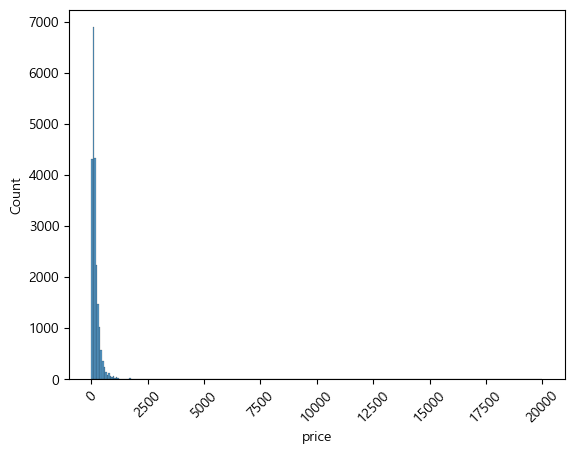

In [97]:
sns.histplot(df['price'])
plt.xticks(rotation=45)
plt.show()          #20000달러때문에 그래프가 너무 안이쁘다 . .

In [98]:
(len(df[df['price'] >= 1000])/ len(df['price'])) * 100  #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도

1.4434283665052896

In [99]:
print("500달러 이상:", len(df[df["price"] >= 500]) / len(df['price']) * 100)        #가격이 500달러 이상인 숙소는 전체의 6% 정도
print("1000달러 이상:", len(df[df["price"] >= 1000]) / len(df['price']) * 100)      #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도
print("2000달러 이상:", len(df[df["price"] >= 2000]) / len(df['price']) * 100)      #가격이 2000달러 이상인 숙소는 전체의 0.4% 정도
print("5000달러 이상:", len(df[df["price"] >= 5000]) / len(df['price']) * 100)      #가격이 5000달러 이상인 숙소는 전체의 0.09% 정도
print("10000달러 이상:", len(df[df["price"] >= 10000]) / len(df['price']) * 100)    #가격이 10000달러 이상인 숙소는 전체의 0.04% 정도
print("전체 숙소 수:", len(df['price']))

500달러 이상: 5.899228976152053
1000달러 이상: 1.4434283665052896
2000달러 이상: 0.38999462076385155
5000달러 이상: 0.08517123901739286
10000달러 이상: 0.04930966469428008
전체 숙소 수: 22308


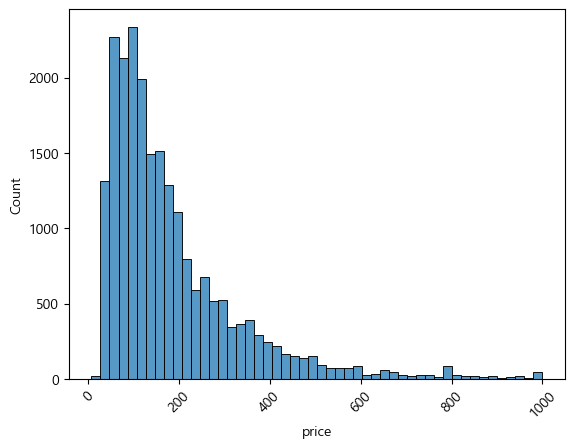

In [100]:
#일단 초고가 상품(가격이 1000달러 이상인 숙소는 전체의 1.5% 정도니까.. 얘네 빼고 보자)
sns.histplot(df[df['price'] <= 1000]['price'], bins=50)
plt.xticks(rotation=45)
plt.show()

### 범주형 변수 인코딩 (문자형 변수 -> 숫자형 변수로 바꿔주기)
- df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개였다.
- 어떤게 범주형 변수일까?

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

In [102]:
df.select_dtypes(include='object').columns

C:\Users\lch\AppData\Local\Temp\ipykernel_26300\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['source', 'name', 'description', 'neighborhood_overview', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review', 'license',
       'instant_bookable'],
      dtype='str')

In [103]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

source 1
name 21342
description 17854
neighborhood_overview 8232
host_name 5343
host_since 4567
host_location 421
host_about 5804
host_response_time 4
host_response_rate 65
host_acceptance_rate 96
host_is_superhost 2
host_neighbourhood 446
host_verifications 6
host_has_profile_pic 2
host_identity_verified 2
neighbourhood 1
neighbourhood_cleansed 221
neighbourhood_group_cleansed 5
property_type 57
room_type 4
bathrooms_text 31


C:\Users\lch\AppData\Local\Temp\ipykernel_26300\753239467.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


amenities 18410
has_availability 1
calendar_last_scraped 2
first_review 3755
last_review 1694
license 1894
instant_bookable 2


In [104]:
str_cols = df.select_dtypes(include='object').columns
str_cols

C:\Users\lch\AppData\Local\Temp\ipykernel_26300\1282968590.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


Index(['source', 'name', 'description', 'neighborhood_overview', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review', 'license',
       'instant_bookable'],
      dtype='str')

In [105]:
df[str_cols].head().T

,0,1,2,3,4
source,city scrape,city scrape,city scrape,city scrape,city scrape
name,Lg Rm in Historic Prospect Heights,"1 Bedroom & your own Bathroom, Elevator Apartment",Luxury Brownstone in Boerum Hill,Spectacular West Harlem Garden Apt,“Work-from-home” from OUR home.
description,Cozy space share in the heart of a great neigh...,Private bedroom with your own bathroom in a 2 ...,"Beautiful, large home in great hipster neighbo...",This is a very large and unique space. An inc...,*Monthly Discount will automatically apply <br...
neighborhood_overview,Full of tree-lined streets and beautiful brown...,"Manhattan, SE corner of 2nd Ave/ E. 110th street","diverse, lively, hip, cool: loaded with restau...",West Harlem is now packed with great restauran...,THE NEIGHBORHOOD:<br />Our apartment is locate...
host_name,Michael,Irene,Sarah,Matthew,Gustavo
host_since,2009-12-11,2010-07-04,2010-07-13,2010-07-14,2010-07-16
host_location,"New York, NY","New York, NY","New York, NY","New York, NY","New York, NY"
host_about,I’m an urban planner working for an internatio...,NaN,I am a lawyer and work as an executive at an a...,I have been a New Yorker for a long time\n and...,I am a music producer. And my wife is a hair s...
host_response_time,NaN,NaN,within a few hours,within an hour,within an hour
host_response_rate,NaN,NaN,100%,100%,100%


In [106]:
unique_counts = df[str_cols].nunique()
unique_counts

source                              1
name                            21342
description                     17854
neighborhood_overview            8232
host_name                        5343
host_since                       4567
host_location                     421
host_about                       5804
host_response_time                  4
host_response_rate                 65
host_acceptance_rate               96
host_is_superhost                   2
host_neighbourhood                446
host_verifications                  6
host_has_profile_pic                2
host_identity_verified              2
neighbourhood                       1
neighbourhood_cleansed            221
neighbourhood_group_cleansed        5
property_type                      57
room_type                           4
bathrooms_text                     31
amenities                       18410
has_availability                    1
calendar_last_scraped               2
first_review                     3755
last_review 

In [107]:
#unique 값이 2~4개인 컬럼 -----------> 사실상 얘네들만 인코딩 하면 되지않나?
low_cardinality = unique_counts[unique_counts.between(2,4)]
low_cardinality.sort_values(ascending=False)

host_response_time        4
room_type                 4
host_is_superhost         2
host_has_profile_pic      2
host_identity_verified    2
calendar_last_scraped     2
instant_bookable          2
dtype: int64

In [109]:
df['room_type'].value_counts() 

room_type
Entire home/apt    12664
Private room        9186
Hotel room           372
Shared room           86
Name: count, dtype: int64

In [ ]:
#unique 값이 7개 이상인 컬럼
high_cardinality = unique_counts[unique_counts >= 7]
high_cardinality.sort_values(ascending=False)

name                      21342
amenities                 18410
description               17854
neighborhood_overview      8232
host_about                 5804
host_name                  5343
host_since                 4567
first_review               3755
license                    1894
last_review                1694
host_neighbourhood          446
host_location               421
neighbourhood_cleansed      221
host_acceptance_rate         96
host_response_rate           65
property_type                57
bathrooms_text               31
dtype: int64

### 수치형 변수 스케일링 (정규화 | 표준화)

In [ ]:
# 숫자형 컬럼만 뽑기
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Unnamed: 0', 'id', 'host_id', 'host_listings_count',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
   

### 피드백 바탕으로 할 일 정리
##### (규제/운영 제약을 반영했을 때) 어떤 지역 × 숙소 타입 × 운영 옵션을 선택하면 예상 연간 매출을 최대화할 수 있는가?
- 구조 분리 
   - **단기**(규제 준수 홈셰어링) : minimum_nights < 30 (+license) 
   - **중장기** : mininum_nights >= 30
   - **호텔형** : room_type == "Hotel" (정통숙박업)

In [115]:
df['room_type'].value_counts()

room_type
Entire home/apt    12664
Private room        9186
Hotel room           372
Shared room           86
Name: count, dtype: int64

In [118]:
property_map = {
    'Room in hotel': 'Lodging',
    'Room in boutique hotel': 'Lodging',

    'Entire rental unit': 'Residential',
    'Private room in rental unit': 'Residential',
    'Private room in home': 'Residential',
    'Entire home': 'Residential',
    'Entire condo': 'Residential',
    'Private room in townhouse': 'Residential',
    'Private room in condo': 'Residential',
    'Entire townhouse': 'Residential',
    'Entire loft': 'Residential',
    'Entire guest suite': 'Residential'
}

df['property_regulation_type'] = df['property_type'].map(property_map)
df['property_regulation_type'] = df['property_regulation_type'].fillna('Other')

##### Residential   (주거형)
##### Lodging       (숙박업형)

In [123]:
def rental_strategy(row):
    
    # 1. 호텔형 (숙박업)
    if row['property_regulation_type'] == 'Lodging':
        return 'hotel'
    
    # 2. 주거형 + 30박 이상
    elif row['minimum_nights'] >= 30:
        return 'residential_mid'
    
    # 3. 주거형 + 30박 미만
    else:
        return 'residential_short'


df['rental_strategy'] = df.apply(rental_strategy, axis=1)
df['rental_strategy'].value_counts()

rental_strategy
residential_mid      17830
residential_short     3452
hotel                 1026
Name: count, dtype: int64

In [124]:
df.groupby('rental_strategy')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
rental_strategy,,,,,,,,
hotel,1026.00,478.49,1151.01,8.00,177.00,265.00,511.25,20000.00
residential_mid,17830.00,197.13,368.10,10.00,78.00,130.00,225.00,15200.00
residential_short,3452.00,221.45,256.98,7.00,105.00,162.00,246.25,5000.00


In [128]:
df["price_log1p"] = np.log1p(df["price"])  # log(1+Fare)
df["price_log1p"]

0       5.30
1       4.42
2       6.64
3       4.94
4       4.88
        ... 
22303   4.29
22304   4.08
22305   5.70
22306   5.30
22307   4.08
Name: price_log1p, Length: 22308, dtype: float64

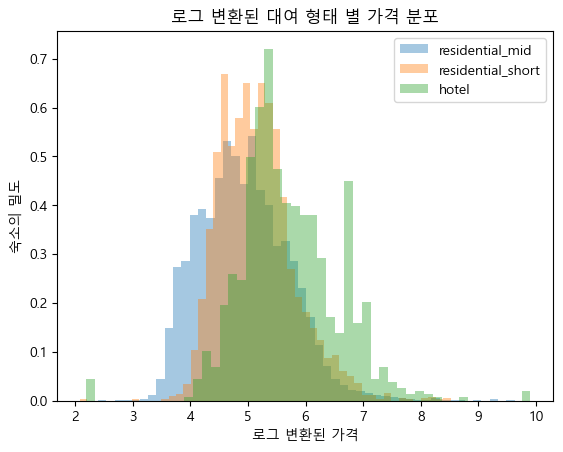

In [184]:
for strategy in df['rental_strategy'].unique():
    subset = df[df['rental_strategy'] == strategy]
    plt.hist(subset['price_log1p'], bins=50, alpha=0.4, label=strategy, density=True)

plt.legend()
plt.xlabel('로그 변환된 가격')
plt.ylabel('숙소의 밀도')
plt.title('로그 변환된 대여 형태 별 가격 분포')
plt.show()

# 오른쪽으로 갈수록 가격이 높고,
# 막대가 높을수록 해당 가격대에 속한 숙소 개수가 많다. 
# density=True 옵션으로 인해, 막대의 높이는 해당 가격대에 속한 숙소의 밀도를 나타냄. 
# 즉, 가격이 특정 범위에 몰려있을수록 막대가 높아짐.

### 연간 매출 추정을 보자. (그룹별 = rental_strategy)

In [157]:
df['estimated_revenue_l365d'].info()

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: estimated_revenue_l365d
Non-Null Count  Dtype  
--------------  -----  
22308 non-null  float64
dtypes: float64(1)
memory usage: 174.4 KB


In [149]:
df['estimated_revenue_l365d'].isna().sum()

np.int64(0)

In [158]:
#연간 매출 추정 분포 확인
df['estimated_revenue_l365d'].describe()

count     22308.00
mean      11901.94
std       24186.92
min           0.00
25%           0.00
50%           0.00
75%       16500.00
max     1020050.00
Name: estimated_revenue_l365d, dtype: float64

In [166]:
df.groupby('rental_strategy')['estimated_revenue_l365d'].describe()
#0인 애들은 뭐지;?

,count,mean,std,min,25%,50%,75%,max
rental_strategy,,,,,,,,
hotel,1026.00,14726.82,26054.76,0.00,0.00,0.00,22029.50,345472.00
residential_mid,17830.00,6627.38,13961.66,0.00,0.00,0.00,8460.00,334305.00
residential_short,3452.00,38306.04,41584.37,0.00,17850.00,29325.00,49470.00,1020050.00


In [161]:
#1년 내내 예약 불가능한 숙소들의 Top 10 매출은 얼마인가? >> 예약이 불가능한데도 매출은 나온다? >> 다른 플랫폼에서 장사하는듯 (airbnb에서 예약 불가)
df['estimated_revenue_l365d'][df['availability_365'] == 0].sort_values(ascending=False).head(10)

15282   114750.00
15281    99450.00
12504    70380.00
14926    68760.00
7100     60720.00
3547     52020.00
17827    45645.00
8122     45135.00
9055     41565.00
14851    36960.00
Name: estimated_revenue_l365d, dtype: float64

In [165]:
(df['estimated_revenue_l365d'] == 0).mean()    #약 54% 정도의 숙소가 연간 추정 매출이 0에 수렴

np.float64(0.5484131253362022)

In [168]:
#각 대여 형태 별로 연간 매출이 0인 숙소의 비율
for strategy in df['rental_strategy'].unique():
    subset = df[df['rental_strategy'] == strategy]
    zero_ratio = (subset['estimated_revenue_l365d'] == 0).mean()
    print(strategy, zero_ratio)
# residential_mid   64%
# hotel             51%
# residential_short 7%

residential_mid 0.6426808749298935
residential_short 0.07213209733487833
hotel 0.5126705653021443


### 정리(airbnb 기준으로)
- 지금까지 한 것만 보면, 단기임대업이 성공확률은 제일 높음(수익 0 인 비율이 7%로 가장 낮으니까?)
- 추가로, 호텔은 절반이 실패(수익없음) 중장기 임대업은 64%가 연간 매출 추정이 0?.. 
- estimated_revenue_l365d 가 어떻게 계산되길래 매출이 아예 안잡히는 걸까? -> 리뷰 상황, 예약 상황도 함께 보면 좋을듯?

In [169]:
#일단 리뷰 확인부터..
df[df['estimated_revenue_l365d'] == 0]['number_of_reviews'].describe()

count   12234.00
mean       16.16
std        43.84
min         0.00
25%         0.00
50%         0.00
75%         9.00
max       644.00
Name: number_of_reviews, dtype: float64

In [182]:
#추정 매출 0이면서 리뷰도 0인 숙소의 비율 약 55%

(df[df['estimated_revenue_l365d'] == 0]['number_of_reviews'] == 0).mean()

np.float64(0.5556645414418833)

In [ ]:
#최근 12개월의 리뷰도 확인 -> 매출이 0인 숙소들의 최근 12개월 리뷰 수는 전부 0이다?... 장사를 안하는 건가
df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'].describe()

count   12234.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: number_of_reviews_ltm, dtype: float64

In [180]:
#추정 매출 0이면서 최근 12개월 리뷰가 0인것들의 비율은 100%
zero_ltm_zero_ratio = (df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'] == 0).mean()
(df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'] == 0).mean()

#airbnb에서는 리뷰수로 매출을 추정하는듯?

np.float64(1.0)

### AIRBNB 는 리뷰 수로 매출을 추정한다. 
- 연간 추정 매출이 0인 숙소는 두가지로 분류할 수 있다. 
    - 1. 유령숙소(약 55%) : 과거 리뷰X / 최근 리뷰X = 비활성 숙소거나, 신규 숙소일 가능성 높음
    - 2. 과거에는 활동 이력이 있는 숙소(약 45%) : 과거 리뷰O / 최근 리뷰X = 휴업, 전략 변경, 시장 이탈 가능성 높음
- 그렇다면, 최근 리뷰가 없어서 매출을 0으로 '추정'한거기 때문에 이걸 사업 실패로 볼 수는 없을 듯. 
    - 상식적으로 단기임대업은 리뷰를 잘 달고.. 중장기로 넘어갈 수록 리뷰를 안다는 사람의 특성? 이 있다고 생각 할 수도 있으니까..

In [179]:
df[df['estimated_revenue_l365d'] == 0]['availability_365'].describe()

count   12234.00
mean      257.55
std       112.86
min         0.00
25%       179.00
50%       288.00
75%       364.00
max       365.00
Name: availability_365, dtype: float64